# NFR Numeric Requirements Bar Chart

This notebook plots bar charts for numeric NFR requirements and provides copy-friendly data output.

In [10]:
import importlib
import subprocess
import sys


def ensure_matplotlib():
    try:
        return importlib.import_module("matplotlib.pyplot")
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
        return importlib.import_module("matplotlib.pyplot")


plt = ensure_matplotlib()

# Numeric NFR results from latest evidence
# Source: k6/out/nfr-validated-report.json (generatedAt: 2026-05-06T07:25:45.280Z)
data = [
    {
        "requirement": "patient_record_p80_300vu_ms",
        "target": 5000,
        "actual": 4675.26826,
        "unit": "ms",
    },
    {
        "requirement": "appointment_write_p75_300vu_ms",
        "target": 7000,
        "actual": 5246.03224,
        "unit": "ms",
    },
    {
        "requirement": "appointment_write_samples_300vu_count",
        "target": 100,
        "actual": 2293,
        "unit": "count",
    },
    {
        "requirement": "http_req_failed_300vu_rate",
        "target": 0.01,
        "actual": 0.0,
        "unit": "rate",
    },
]

for row in data:
    row["headroom"] = row["target"] - row["actual"]
    row["pass"] = (row["actual"] <= row["target"]) if row["unit"] in ["ms", "rate"] else (row["actual"] >= row["target"])

print("NFR numeric table:")
print("requirement,target,actual,unit,headroom,pass")
for row in data:
    print(f"{row['requirement']},{row['target']},{row['actual']},{row['unit']},{row['headroom']},{row['pass']}")

NFR numeric table:
requirement,target,actual,unit,headroom,pass
patient_record_p80_300vu_ms,5000,4675.26826,ms,324.7317400000002,True
appointment_write_p75_300vu_ms,7000,5246.03224,ms,1753.9677600000005,True
appointment_write_samples_300vu_count,100,2293,count,-2193,True
http_req_failed_300vu_rate,0.01,0.0,rate,0.01,True


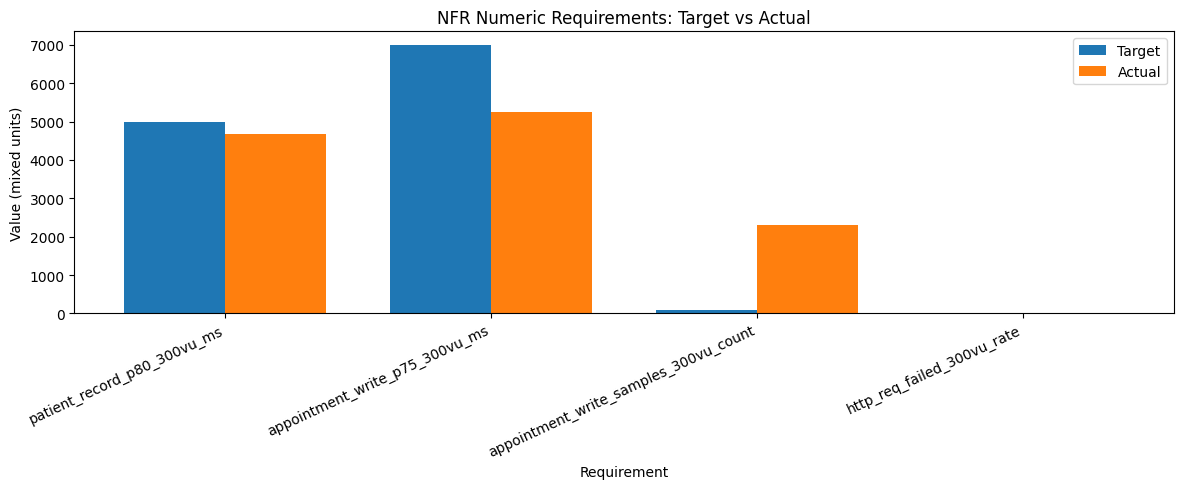

In [11]:
# Grouped bar chart: target vs actual (all numeric requirements)
requirements = [row["requirement"] for row in data]
targets = [row["target"] for row in data]
actuals = [row["actual"] for row in data]

x = range(len(requirements))
bar_width = 0.38

plt.figure(figsize=(12, 5))
plt.bar([i - bar_width / 2 for i in x], targets, width=bar_width, label="Target")
plt.bar([i + bar_width / 2 for i in x], actuals, width=bar_width, label="Actual")

plt.title("NFR Numeric Requirements: Target vs Actual")
plt.xlabel("Requirement")
plt.ylabel("Value (mixed units)")
plt.xticks(list(x), requirements, rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

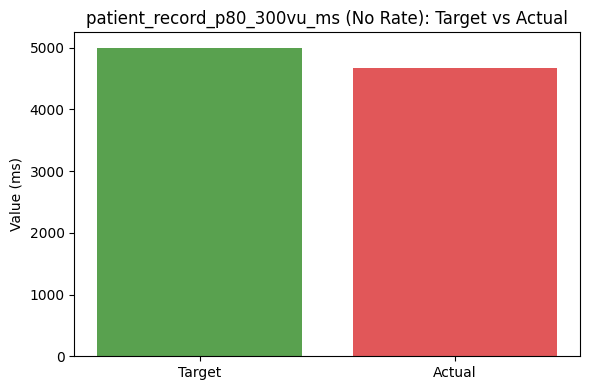

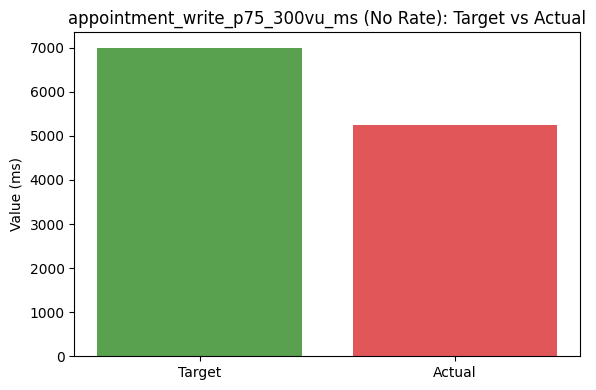

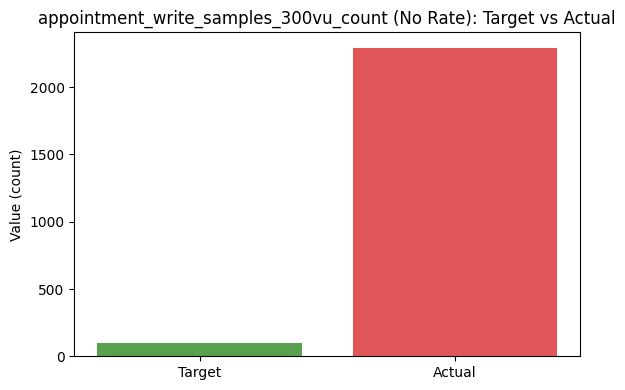

In [8]:
# Optional: individual charts without the rate metric for clearer ms/count scale
data_no_rate = [row for row in data if row["unit"] != "rate"]

for row in data_no_rate:
    plt.figure(figsize=(6, 4))
    plt.bar(["Target", "Actual"], [row["target"], row["actual"]], color=["#59a14f", "#e15759"])

    plt.title(f"{row['requirement']} (No Rate): Target vs Actual")
    plt.ylabel(f"Value ({row['unit']})")
    plt.tight_layout()
    plt.show()

In [9]:
# Copy-friendly CSV output (copy from this cell output)
headers = ["requirement", "target", "actual", "unit", "headroom", "pass"]
print(",".join(headers))
for row in data:
    print(",".join([
        str(row["requirement"]),
        str(row["target"]),
        str(row["actual"]),
        str(row["unit"]),
        str(row["headroom"]),
        str(row["pass"]),
    ]))

requirement,target,actual,unit,headroom,pass
patient_record_p80_300vu_ms,5000,4675.26826,ms,324.7317400000002,True
appointment_write_p75_300vu_ms,7000,5246.03224,ms,1753.9677600000005,True
appointment_write_samples_300vu_count,100,2293,count,-2193,True
http_req_failed_300vu_rate,0.01,0.0,rate,0.01,True
